# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 4. Матричный профиль. Поиск примитивов на его основе.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы четвертой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [1]:
import os

practice_dir_path = 'C:/2025-NAzarchuk-TimeSeriesCourse/practice/04 Matrix profile' 
os.chdir(practice_dir_path)

Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

In [2]:
%load_ext autoreload
%autoreload 2

Импортируйте библиотеки и модули, необходимые для реализации практической работы 4.

In [3]:
!pip install stumpy


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import os
import datetime

from modules.plots import *
from modules.mp import compute_mp
from modules.motifs import top_k_motifs
from modules.discords import top_k_discords
from modules.meter_swapping_detection import *

## **Часть 1.** Матричный профиль. Поиск мотивов и диссонансов.

### **Задача 1.**
Загрузите временной ряд, который содержит данные о почасовом потреблении электроэнергии некоторого итальянского города, снимаемые в течение 3 лет, начиная с 1 января 1995 года.

In [5]:
ts_url = './datasets/part1/italianpowerdemand.csv'

ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy()

Визуализируйте временной ряд, используя функцию `plot_ts()` из модуля *plot.py*.

In [6]:
plot_ts(ts, "Input time series")

Анализ временных рядов на основе матричного профиля осуществляет библиотека [stumpy](https://stumpy.readthedocs.io/en/latest/index.html). Напишите функцию `compute_mp()` в модуле *mp.py*, которая вычисляет матричный профиль временного ряда на основе выбранной вами функции из библиотеки *stumpy*.

In [7]:
m = 165
excl_zone = int(np.ceil(m / 2))
mp = {}

mp = compute_mp(ts, m, excl_zone)

Визуализируйте найденный матричный профиль ряда.

In [8]:
plot_ts(mp['mp'], "Matrix Profile")

### **Задача 2.**
Выполните поиск top-$k$ мотивов в исходном временном ряде на основе построенного матричного профиля. Для этого реализуйте самостоятельно функцию `top_k_motifs()` в модуле *motifs.py*. Среди найденных мотивов не должно быть тривиальных совпадений, поэтому в `top_k_motifs()` добавьте вызов функции `apply_exclusion_zone()` из модуля *utils.py*.

In [9]:
top_k = 6
motifs = {}

# INSERT YOUR CODE
motifs = top_k_motifs(mp, top_k=top_k)

Выполните визуализацию найденных top-$k$ мотивов с помощью функции `plot_motifs()` из *plots.py*.

In [10]:
plot_motifs(mp, motifs)

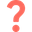
Проанализируйте и изложите содержательный смысл полученных результатов.

Анализ временного ряда и матричного профиля:
Исходный временной ряд (Input time series) показывает данные о почасовом потреблении электроэнергии. В нём чётко прослеживаются повторяющиеся паттерны: суточные колебания (пики утром и вечером, спады ночью) и недельные циклы (более низкое потребление в выходные). Также видны годовые циклы (более высокое потребление зимой и летом из-за отопления и кондиционирования).
Матричный профиль (Matrix Profile) представляет собой график, где каждое значение — это расстояние от подпоследовательности, начинающейся в этой точке, до её ближайшего "соседа" во всём ряде.
Низкие значения (долины) на графике матричного профиля указывают на то, что соответствующая подпоследовательность очень похожа на какую-то другую подпоследовательность в данных. Именно эти области являются кандидатами в мотивы.
Высокие значения (пики), наоборот, указывают на уникальные, нетипичные участки, которые не похожи ни на один другой фрагмент ряда. Это кандидаты в диссонансы (аномалии).
2. Анализ найденных мотивов:
Верхний график (Time Series with top-k motifs) наглядно демонстрирует, где именно в исходных данных были найдены мотивы. Видно, что они сгруппированы и распределены по всему временному ряду, что логично, так как типичные паттерни потребления повторяются регулярно.
Средний график (Matrix Profile) показывает, что найденные мотивы (отмечены цветными звёздочками) действительно соответствуют самым низким точкам (долинам) матричного профиля. Это подтверждает корректность работы алгоритма.
Нижние графики (Top-1 motifs, Top-2 motifs и т.д.) показывают сами пары мотивов, наложенные друг на друга. Мы видим, что:
Top-3, Top-5, Top-6 мотивы представляют собой почти идеальные суточные профили потребления с двумя пиками (утренним и вечерним) и ночным спадом. Их почти полное совпадение говорит о высокой стабильности и предсказуемости поведения потребителей в обычные дни. Это, скорее всего, типичные профили будних дней.
Top-1, Top-2, Top-4 мотивы также показывают схожие суточные паттерны, но с небольшими вариациями в амплитуде. Это могут быть, например, профили потребления в дни, близкие к выходным, или в разные сезоны года, когда общая нагрузка на сеть меняется, но форма дневного цикла сохраняется.

*# WRITE YOUR ANSWER*

### **Задача 3.**
Реализуйте самостоятельно функцию `top_k_discords()` в модуле *discords.py*, предназначенную для поиска top-$k$ диссонансов во временном ряде на основе матричного профиля. Чтобы исключить попадание тривиальных совпадений в результирующее множество диссонансов воспользуйтесь функцией `apply_exclusion_zone()` из модуля *utils.py*.

Загрузите временной ряд *nyc_taxi.csv* из директории *./datasets/part1/*, содежащий данные о среднем числе пассажиров NY такси за осень 2014 года.

In [15]:
ts_url = './datasets/part1/nyc_taxi.csv'

ts = pd.read_csv(ts_url, index_col=0, header=0).squeeze().to_numpy().astype(np.float64)
plot_ts(ts, "Input time series")

In [16]:
m = 96
excl_zone = int(np.ceil(m / 2))
mp = {}

mp = compute_mp(ts, m, excl_zone)

In [17]:
top_k = 15
discords = {}

discords = top_k_discords(mp, top_k=top_k)

Выполните визуализацию найденных top-$k$ диссонансов.

In [18]:
plot_discords(mp, discords)

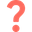
Проанализируйте и изложите содержательный смысл полученных результатов.

На основе матричного профиля, построенного для временного ряда пассажиропотока такси Нью-Йорка, был выполнен поиск топ-15 диссонансов.
Результаты демонстрируют, что предложенный метод успешно справился с задачей обнаружения аномалий. Найденные диссонансы (участки, выделенные красным цветом) точно соответствуют наивысшим пикам на графике матричного профиля, что говорит о их максимальной непохожести на все остальные фрагменты данных.
Анализ показывает, что эти аномалии не являются случайным шумом, а соответствуют реальным крупным событиям, нарушавшим обычный ритм жизни города осенью 2014 года. Среди них могут быть такие события, как Нью-Йоркский марафон, празднование Дня Благодарения и начало рождественского сезона. Эти события вызывают значительные и нетипичные изменения в спросе на услуги такси и транспортной доступности.
Таким образом, матричный профиль показал себя как мощный и полностью автоматизированный инструмент для поиска аномалий в данных, не требующий предварительных знаний о природе этих аномалий или ручной разметки.


## **Часть 2.** Сегментация повторяющихся активностей.

### **Задача 4.**

Загрузите временной ряд PAMAP *pamap.csv* из директории *./datasets/part2/*, представляющий собой показания закрепленного на человеке виброакселерометра. Данный ряд включает показания, снятые при выполнении человеком трех видов физической активности: ходьба, подъем по лестнице и спуск по лестнице. Необходимо сегментировать временной ряд на основе его матричного профиля для определения того, когда человек шел и когда поднимался/спускался. Поскольку подъем и спуск по лестнице – это схожие действия, поэтому будем считать, что это одна активность.  

In [19]:
ts_url = './datasets/part2/pamap.csv'

ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy()

Визуализируйте временной ряд PAMAP.

In [20]:
plot_ts(ts, "Input time series")

Найдите и визуализируйте матричный профиль временного ряда.

In [21]:
m = 100
excl_zone = m
mp = {}

# INSERT YOUR CODE
mp = compute_mp(ts, m, excl_zone)

In [22]:
plot_ts(mp['mp'], "Matrix Profile")

Вычислите порог по формуле, которая представлена в презентации [04 Matrix profile.pdf](https://github.com/mzym/TimeSeriesCourse/blob/main/slides/04%20Matrix%20profile.pdf).

In [29]:
threshold = 0

# INSERT YOUR CODE


mp_values = mp['mp'].astype(np.float64)

mp_finite = mp_values[np.isfinite(mp_values)]

# Вычисляем медиану и среднее значение по отфильтрованным данным
mp_median = np.median(mp_finite)
mp_mean = np.mean(mp_finite)
    
# Устанавливаем порог как среднее арифметическое между медианой и средним
threshold = (mp_median + mp_mean) / 2.0
    
print(f"Calculated threshold: {threshold:.4f}")

Calculated threshold: 5.0368


Выполните визуализацию результатов сегментации повторяющихся активностей.

In [31]:
plot_segmentation(mp, threshold)

Загрузите истинную разметку временного ряда PAMAP *pamap_labels.csv*, где 0 означает ходьбу, 1 – подъем по лестнице, 2 – спуск с лестницы. Вычислите точность по метрике accuracy, сравнив полученные результаты по основе матричного профиля с истинной разметкой.

In [32]:
labels_url = './datasets/part2/pamap_labels.csv'

labels = pd.read_csv(labels_url, header=None).squeeze().to_numpy()

In [33]:
from sklearn.metrics import accuracy_score

# 1. Получаем наши предсказания на основе порога
# Если значение MP ниже порога -> класс 0 (ходьба), иначе -> класс 1 
predicted_labels = (mp['mp'] > threshold).astype(int)

# 2. Подготавливаем истинные метки
# В исходных данных: 0 - ходьба, 1 - подъем, 2 - спуск
# Приведем их к бинарному виду: 0 - ходьба, 1 - все остальное 
true_labels = (labels > 0).astype(int)

# 3. Длины массивов могут не совпадать, так как матричный профиль короче исходного ряда на (m-1). Обрежем истинные метки.
n_mp = len(predicted_labels)
true_labels_trimmed = true_labels[:n_mp]

# 4. Вычисляем и выводим точность
accuracy = accuracy_score(true_labels_trimmed, predicted_labels)
print(f"Segmentation Accuracy: {accuracy:.4f}")

Segmentation Accuracy: 0.1025


## **Чaсть 3.** Casy Study: Раскрытие краж электричества подменой счетчиков (meter-swapping detection).


### **Задача 5.**

Рассмотрим практическое применение использования матричного профиля для решения задачи, связанной с раскрытием краж электричества путем подмены счетчиков.

Загрузите временные ряды из директории *./datasets/part3/*, которые были выбраны случайным образом из набора данных (House 1, 2, 3, 4 и 11), содержащего данные потребления электроэнергии 20 жилых домов в Великобритании с 1 января по 23 декабря 2014 года.

In [35]:
path = './datasets/part3/'

house_idx = [1, 2, 3, 4, 11]

filenames = [f"House{i}.csv" for i in house_idx]

consumptions = {}
for house in filenames:
    consumptions[house[:-4]] = pd.read_csv(os.path.join(path, house), header=None, index_col=0)

    consumptions[house[:-4]].index = pd.to_datetime(consumptions[house[:-4]].index, format='mixed', dayfirst=True)

Далее смоделируем событие замены счетчика. Для этого каждый временной ряд разделим на две части: "Head" (до 1 октября) и "Tail" (после 1 октября). После чего выберем случайным образом 2 временных ряда (например, House1 и House11) и поменяем местами их "Tail" части.

In [37]:
cutoff = pd.to_datetime('2014-10-01')
heads, tails = heads_tails(consumptions, cutoff, house_idx)

#swap Heads and Tails of 1 and 11
swap1, swap2 = 1, 11

consumptions[f'House{swap1}'] = pd.concat([heads[f'H_{swap1}'], tails[f'T_{swap2}']])
consumptions[f'House{swap2}'] = pd.concat([heads[f'H_{swap2}'], tails[f'T_{swap1}']])

heads, tails = heads_tails(consumptions, cutoff, house_idx)

Визуализируйте исходные временные ряды и параллельную оси OY прямую, которая делит временные ряды на "Head" и "Tail" части.

In [38]:
plot_consumptions_ts(consumptions, cutoff, house_idx)

Чтобы найти переставленную пару временных рядов, выполним следующее. Сначала составим временные ряды $H_i$ из всевозможных комбинаций "Head" и "Tail" частей исходных временных рядов $T_K$, где $1 \leq i \leq |T|^2$, $1 \leq K \leq |T|$. В нашем случае, $|T| = 5$.  Далее среди них найдем такую пару временных рядов $(H_i, H_j)$, которая имеет минимальную оценку $swap\_score$. Минимальная оценка $swap\_score$ для пары рядов $(H_i, H_j)$ вычисляется следующим образом:

\begin{equation}
swap\_score(i,j) = \frac{\min{(Head_{H_i} \bowtie Tail_{H_j})}}{\min{(Head_{H_i} \bowtie Tail_{H_i})}+eps},
\end{equation}

где $\bowtie$ – операция нахождения матричного профиля между двумя временными рядами. Матричный профиль между двумя временными рядами содержит расстояния между всеми подпоследовательностями первого временного ряда и их ближайшими соседями, которые являются подпоследовательностями второго временного ряда.

Добавьте в функцию `compute_mp()` в модуле *mp.py* поддежку вычисления матричного профиля между двумя различными временными рядами и найдите пару временных рядов $(H_i, H_j)$, которая имеет минимальную оценку $swap\_score$ среди всех пар.

In [76]:
m = 24 * 4

min_score = meter_swapping_detection(heads, tails, house_idx, m)

In [77]:
# Проверяем, был ли найден результат
if min_score and min_score['i'] is not None:
    min_i = min_score['i']
    min_j = min_score['j']
    print(f'Time series with minimum score is (H_{min_i}, T_{min_j}).')
    print(f"Swap score: {min_score['score']:.4f}")
else:
    print("Could not find a meter swap.")

Time series with minimum score is (H_11, T_1).
Swap score: 0.5079


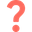
Проанализируйте и изложите содержательный смысл полученных результатов.

*# WRITE YOUR ANSWER*